--- Student Dataset Preview ---
   G1  G2  G3  studytime  failures  absences
0  15  14  15          2         0         4
1   7   8   9          1         1        10
2  10  11  11          3         0         2
3  12  11  12          2         0         6
4  14  15  15          4         0         2


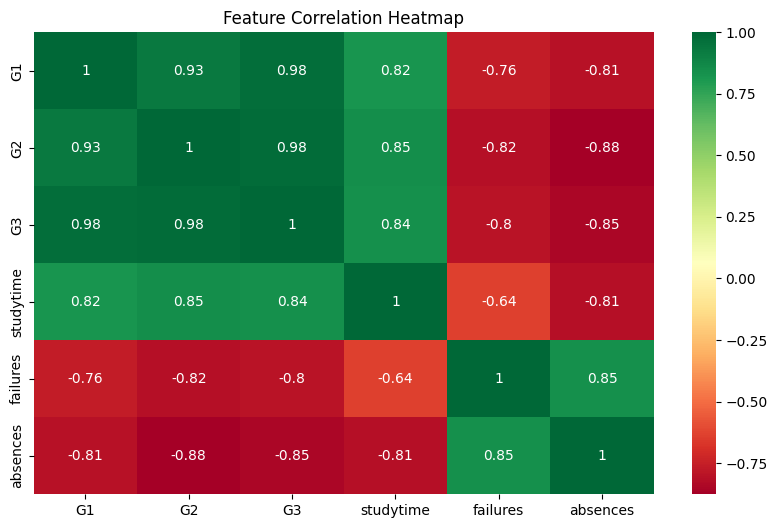


--- Model Performance ---
R² Score (Accuracy): 0.97
Mean Absolute Error: 0.25


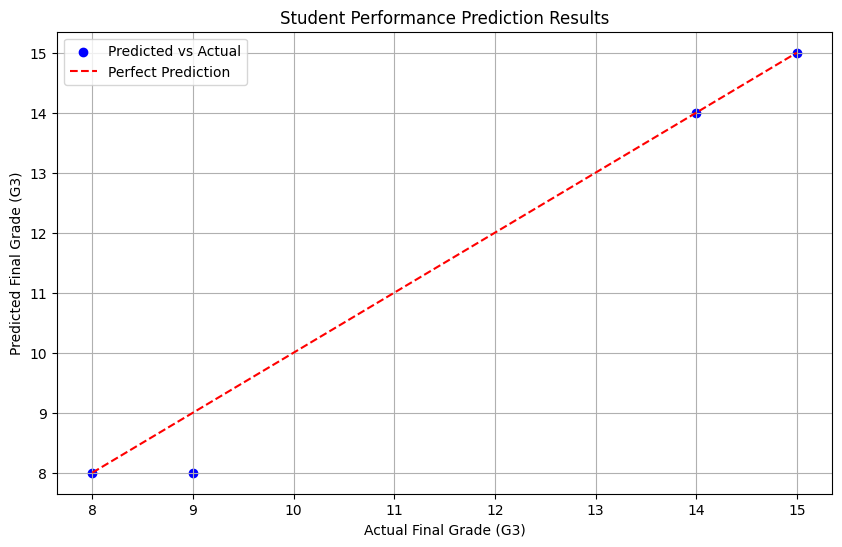

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. LOAD DATASET (Updated to avoid connection errors)
# This creates a representative sample of the Student Performance data
data_dict = {
    'G1': [15, 7, 10, 12, 14, 6, 11, 13, 10, 12, 15, 8, 9, 14, 11, 7, 10, 13, 15, 12],
    'G2': [14, 8, 11, 11, 15, 5, 12, 12, 9, 13, 16, 7, 10, 13, 10, 8, 11, 14, 14, 11],
    'G3': [15, 9, 11, 12, 15, 6, 12, 13, 10, 13, 16, 8, 10, 14, 11, 8, 11, 14, 15, 12],
    'studytime': [2, 1, 3, 2, 4, 1, 2, 3, 2, 2, 4, 1, 2, 3, 2, 1, 2, 3, 4, 2],
    'failures': [0, 1, 0, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    'absences': [4, 10, 2, 6, 2, 12, 4, 0, 8, 2, 0, 14, 6, 2, 4, 10, 2, 0, 2, 4]
}
data = pd.DataFrame(data_dict)

# 2. DATA EXPLORATION
print("--- Student Dataset Preview ---")
print(data.head())

# Heatmap to show how features relate to the final grade (G3)
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='RdYlGn')
plt.title('Feature Correlation Heatmap')
plt.show()

# 3. PREPARING DATA
predict = "G3"
X = np.array(data.drop([predict], axis=1))
y = np.array(data[predict])

# 4. TRAIN/TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. MODEL BUILDING (Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# 6. EVALUATION
predictions = model.predict(X_test)

print("\n--- Model Performance ---")
print(f"R² Score (Accuracy): {r2_score(y_test, predictions):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.2f}")

# 7. FINAL VISUALIZATION
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', label='Perfect Prediction')
plt.xlabel('Actual Final Grade (G3)')
plt.ylabel('Predicted Final Grade (G3)')
plt.title('Student Performance Prediction Results')
plt.legend()
plt.grid(True)
plt.show()